### Reviewer R2.4: load object-level clDice evaluation results

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats


PROJECT_ROOT = Path(
    r"C:\Users\abd93000\PycharmProjects\cnt_project_v2"
)

RUNS_ROOT = PROJECT_ROOT / "global_outputs" / "runs"

SEEDS = [0, 1, 2, 42, 123]

NANOVISION_EVAL_DIR = (
    Path("eval")
    / "instance_metrics_unfiltered_iou_cldice_chamfer_hausdorff"
)

STARDIST_EVAL_DIR = (
    Path("eval")
    / "full_instance_metrics_iou_cldice_chamfer_hausdorff"
)

CSV_NAME = "object_metrics_per_image_threshold.csv"


NANOVISION_RUN_TEMPLATE = (
    "nanovision_centerness_stratified_seed_{seed}_fresh_"
    "100epochs_64rays_grid2x2_optimized_test_no_smoothing"
)

STARDIST_RUN_TEMPLATE = (
    "stardist_native_nanovision_standard_stratified_seed_{seed}_fresh_"
    "100epochs_64rays_grid2x2_optimized_test"
)


def load_seed_object_f1(run_name, eval_dir):
    path = RUNS_ROOT / run_name / eval_dir / CSV_NAME

    print("Loading:", path)

    df = pd.read_csv(path)

    rows = df[
        (df["matching_metric"] == "cldice")
        & np.isclose(df["threshold"], 0.5)
    ]

    return rows["f1_score"].mean()

def load_seed_pixel_f1(run_name, eval_dir):
    path = RUNS_ROOT / run_name / eval_dir / "pixel_metrics_per_image.csv"

    print("Loading:", path)

    df = pd.read_csv(path)

    return df["pixel_f1"].mean()

In [2]:
EVAL_DIR = (
    Path("eval")
    / "instance_metrics_unfiltered_iou_cldice_chamfer_hausdorff"
)

In [3]:
# %%
def mean_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=float)

    mean = values.mean()
    half_width = (
        stats.sem(values)
        * stats.t.ppf(
            (1 + confidence) / 2,
            len(values) - 1,
        )
    )

    return mean, mean - half_width, mean + half_width


nanovision_seed_f1 = [
    load_seed_object_f1(
        NANOVISION_RUN_TEMPLATE.format(seed=seed),
        NANOVISION_EVAL_DIR,
    )
    for seed in SEEDS
]

stardist_seed_f1 = [
    load_seed_object_f1(
        STARDIST_RUN_TEMPLATE.format(seed=seed),
        STARDIST_EVAL_DIR,
    )
    for seed in SEEDS
]


NANOVISION_OBJECT_F1, nanovision_ci_low, nanovision_ci_high = mean_ci(
    nanovision_seed_f1
)
NANOVISION_OBJECT_CI = (
    nanovision_ci_low,
    nanovision_ci_high,
)

STARDIST_OBJECT_F1, stardist_ci_low, stardist_ci_high = mean_ci(
    stardist_seed_f1
)
STARDIST_OBJECT_CI = (
    stardist_ci_low,
    stardist_ci_high,
)


print("NanoVision seed means:", nanovision_seed_f1)
print(
    f"NanoVision: {NANOVISION_OBJECT_F1:.3f} "
    f"[{NANOVISION_OBJECT_CI[0]:.3f}, {NANOVISION_OBJECT_CI[1]:.3f}]"
)

print()

print("StarDist seed means:", stardist_seed_f1)
print(
    f"StarDist: {STARDIST_OBJECT_F1:.3f} "
    f"[{STARDIST_OBJECT_CI[0]:.3f}, {STARDIST_OBJECT_CI[1]:.3f}]"
)

nanovision_seed_pixel_f1 = [
    load_seed_pixel_f1(
        NANOVISION_RUN_TEMPLATE.format(seed=seed),
        NANOVISION_EVAL_DIR,
    )
    for seed in SEEDS
]

stardist_seed_pixel_f1 = [
    load_seed_pixel_f1(
        STARDIST_RUN_TEMPLATE.format(seed=seed),
        STARDIST_EVAL_DIR,
    )
    for seed in SEEDS
]


NANOVISION_PIXEL_F1, nanovision_pixel_ci_low, nanovision_pixel_ci_high = mean_ci(
    nanovision_seed_pixel_f1
)
NANOVISION_PIXEL_CI = (
    nanovision_pixel_ci_low,
    nanovision_pixel_ci_high,
)

STARDIST_PIXEL_F1, stardist_pixel_ci_low, stardist_pixel_ci_high = mean_ci(
    stardist_seed_pixel_f1
)
STARDIST_PIXEL_CI = (
    stardist_pixel_ci_low,
    stardist_pixel_ci_high,
)


print()
print("NanoVision pixel F1 seed means:", nanovision_seed_pixel_f1)
print(
    f"NanoVision Pixel F1: {NANOVISION_PIXEL_F1:.3f} "
    f"[{NANOVISION_PIXEL_CI[0]:.3f}, {NANOVISION_PIXEL_CI[1]:.3f}]"
)

print()

print("StarDist pixel F1 seed means:", stardist_seed_pixel_f1)
print(
    f"StarDist Pixel F1: {STARDIST_PIXEL_F1:.3f} "
    f"[{STARDIST_PIXEL_CI[0]:.3f}, {STARDIST_PIXEL_CI[1]:.3f}]"
)

Loading: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\nanovision_centerness_stratified_seed_0_fresh_100epochs_64rays_grid2x2_optimized_test_no_smoothing\eval\instance_metrics_unfiltered_iou_cldice_chamfer_hausdorff\object_metrics_per_image_threshold.csv
Loading: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\nanovision_centerness_stratified_seed_1_fresh_100epochs_64rays_grid2x2_optimized_test_no_smoothing\eval\instance_metrics_unfiltered_iou_cldice_chamfer_hausdorff\object_metrics_per_image_threshold.csv
Loading: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\nanovision_centerness_stratified_seed_2_fresh_100epochs_64rays_grid2x2_optimized_test_no_smoothing\eval\instance_metrics_unfiltered_iou_cldice_chamfer_hausdorff\object_metrics_per_image_threshold.csv
Loading: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\nanovision_centerness_stratified_seed_42_fresh_100epochs_64rays_grid2x2_optimized_test_n

### Direct whole-CNT StarDist vs NanoVision SYM (fragment + merge).
Mean values and 95% Student's t confidence intervals are calculated
from the five evaluation seeds in the preceding cells.

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\ablation\stardist_whole_cnt_vs_nanovision_fragment_merge.svg
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\ablation\stardist_whole_cnt_vs_nanovision_fragment_merge.png


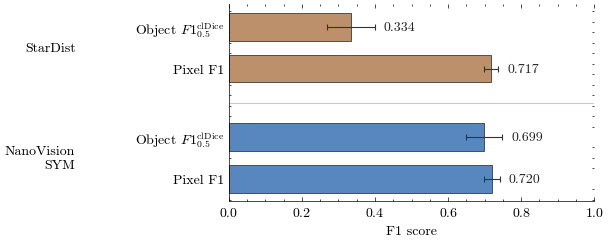

In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import scienceplots

    plt.style.use(["science", "no-latex"])
except ImportError:
    pass


# ------------------------------------------------------------------
# Output
# ------------------------------------------------------------------

OUTPUT_DIR = (
    PROJECT_ROOT
    / "notebooks"
    / "paper_figures"
    / "outputs"
    / "ablation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FILENAME_STEM = (
    "stardist_whole_cnt_vs_nanovision_fragment_merge"
)


# ------------------------------------------------------------------
# Prepare plot data
# ------------------------------------------------------------------

y_positions = np.array([
    3.2,
    2.4,
    1.1,
    0.3,
])

metric_labels = [
    r"Object $F1^{\mathrm{clDice}}_{0.5}$",
    "Pixel F1",
    r"Object $F1^{\mathrm{clDice}}_{0.5}$",
    "Pixel F1",
]

values = np.array([
    STARDIST_OBJECT_F1,
    STARDIST_PIXEL_F1,
    NANOVISION_OBJECT_F1,
    NANOVISION_PIXEL_F1,
])

ci_low = np.array([
    STARDIST_OBJECT_CI[0],
    STARDIST_PIXEL_CI[0],
    NANOVISION_OBJECT_CI[0],
    NANOVISION_PIXEL_CI[0],
])

ci_high = np.array([
    STARDIST_OBJECT_CI[1],
    STARDIST_PIXEL_CI[1],
    NANOVISION_OBJECT_CI[1],
    NANOVISION_PIXEL_CI[1],
])

xerr = np.vstack([
    values - ci_low,
    ci_high - values,
])

colors = [
    "#B88A63",
    "#B88A63",
    "#4F81BD",
    "#4F81BD",
]


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(5.8, 2.7),
)

bars = ax.barh(
    y_positions,
    values,
    height=0.52,
    color=colors,
    edgecolor="#333333",
    linewidth=0.6,
    alpha=0.95,
    xerr=xerr,
    error_kw={
        "ecolor": "#333333",
        "elinewidth": 0.8,
        "capsize": 2.5,
        "capthick": 0.8,
    },
)


# ------------------------------------------------------------------
# Metric labels
# ------------------------------------------------------------------

ax.set_yticks(y_positions)
ax.set_yticklabels(metric_labels)


# ------------------------------------------------------------------
# Method labels
# ------------------------------------------------------------------

ax.text(
    -0.42,
    np.mean(y_positions[:2]),
    "StarDist",
    ha="right",
    va="center",
    fontweight="bold",
    transform=ax.get_yaxis_transform(),
)

ax.text(
    -0.42,
    np.mean(y_positions[2:]),
    "NanoVision\nSYM",
    ha="right",
    va="center",
    fontweight="bold",
    transform=ax.get_yaxis_transform(),
)


# ------------------------------------------------------------------
# Divider
# ------------------------------------------------------------------

ax.axhline(
    y=1.75,
    color="#BDBDBD",
    linewidth=0.8,
    linestyle="-",
    alpha=0.8,
)


# ------------------------------------------------------------------
# Numerical mean values
# ------------------------------------------------------------------

TEXT_PADDING = 0.025

for bar, value, upper_ci in zip(
    bars,
    values,
    ci_high,
):
    y = (
        bar.get_y()
        + bar.get_height() / 2
    )

    text_x = upper_ci + TEXT_PADDING

    ax.text(
        text_x,
        y,
        f"{value:.3f}",
        va="center",
        ha="left",
        color="#222222",
    )


# ------------------------------------------------------------------
# Axes
# ------------------------------------------------------------------

ax.set_xlim(0, 1)
ax.set_xlabel("F1 score")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
)

ax.tick_params(
    axis="x",
    direction="in",
)

ax.set_axisbelow(True)

plt.subplots_adjust(
    left=0.35,
    right=0.98,
    bottom=0.22,
    top=0.95,
)


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

svg_path = OUTPUT_DIR / f"{FILENAME_STEM}.svg"
png_path = OUTPUT_DIR / f"{FILENAME_STEM}.png"

fig.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

fig.savefig(
    png_path,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
)

print(f"Saved: {svg_path}")
print(f"Saved: {png_path}")

plt.show()